# Data Exploration - Retrieval Evaluation Results

**Zweck:** Erste Analyse der Evaluation-Ergebnisse, Data Quality Checks

**Input:** `results_combined.csv` (aus 03_run_evaluation.py)

**Output:** Verständnis der Datenstruktur, Identifikation von Problemen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load Data

In [2]:
# Path setup - use absolute path
import os
project_root = Path(os.getcwd()).parent  # notebooks/ -> BA/
results_file = project_root / 'results' / 'evaluation' / 'results_combined.csv'

print(f"📂 Project root: {project_root}")
print(f"📂 Results file: {results_file}")

# Check if exists
if not results_file.exists():
    print(f"\n❌ ERROR: Results file not found!")
    print(f"   Run 03_run_evaluation.py first!")
else:
    print(f"✅ Results file found")

# Load
df = pd.read_csv(results_file)

print(f"\n✅ Loaded: {len(df)} rows")
print(f"   Questions: {df['question_id'].nunique()}")
print(f"   Modes: {df['mode'].unique()}")
print(f"   k-values: {sorted(df['k'].unique())}")

📂 Project root: C:\Users\Julian\Desktop\BA
📂 Results file: C:\Users\Julian\Desktop\BA\results\evaluation\results_combined.csv
✅ Results file found

✅ Loaded: 294 rows
   Questions: 50
   Modes: ['flat' 'hierarchical']
   k-values: [3, 5, 10]


## 2. Dataset Overview

In [3]:
# First rows
display(df.head())

# Data types
print("\nData Types:")
display(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
display(df[['recall', 'precision', 'mrr']].describe())

,question_id,query,type,difficulty,mode,k,recall,precision,mrr,num_ground_truth,num_overlap
0,1,Was ist EDI (Electronic Data Interchange)?,definition,beginner,flat,3,0.0,0.0,0.0,1,0
1,1,Was ist EDI (Electronic Data Interchange)?,definition,beginner,flat,5,0.0,0.0,0.0,1,0
2,1,Was ist EDI (Electronic Data Interchange)?,definition,beginner,flat,10,0.0,0.0,0.0,1,0
3,2,Was ist ein XML-Schema (XSD)?,definition,beginner,flat,3,0.0,0.0,0.0,2,0
4,2,Was ist ein XML-Schema (XSD)?,definition,beginner,flat,5,0.0,0.0,0.0,2,0



Data Types:


question_id           int64
query                object
type                 object
difficulty           object
mode                 object
k                     int64
recall              float64
precision           float64
mrr                 float64
num_ground_truth      int64
num_overlap           int64
dtype: object


Basic Statistics:


,recall,precision,mrr
count,294.000000,294.000000,294.000000
mean,0.393440,0.162358,0.429511
std,0.370086,0.176975,0.423105
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.450000,0.100000,0.291667
75%,0.500000,0.200000,1.000000
max,1.000000,1.000000,1.000000


## 3. Data Quality Checks

In [4]:
# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Check for mismatched question counts
print("\nQuestions per Mode (k=5):")
mode_counts = df[df['k'] == 5].groupby('mode')['question_id'].nunique()
display(mode_counts)

# Identify missing questions in hierarchical
flat_qids = set(df[(df['mode'] == 'flat') & (df['k'] == 5)]['question_id'])
hier_qids = set(df[(df['mode'] == 'hierarchical') & (df['k'] == 5)]['question_id'])

missing_in_hier = flat_qids - hier_qids

if missing_in_hier:
    print(f"\n⚠️  Questions missing in hierarchical: {sorted(missing_in_hier)}")
else:
    print("\n✅ All questions present in both modes")

Missing Values:


question_id         0
query               0
type                0
difficulty          0
mode                0
k                   0
recall              0
precision           0
mrr                 0
num_ground_truth    0
num_overlap         0
dtype: int64


Questions per Mode (k=5):


mode
flat            50
hierarchical    48
Name: question_id, dtype: int64


⚠️  Questions missing in hierarchical: [46, 50]


## 4. Distribution of Question Types & Difficulty

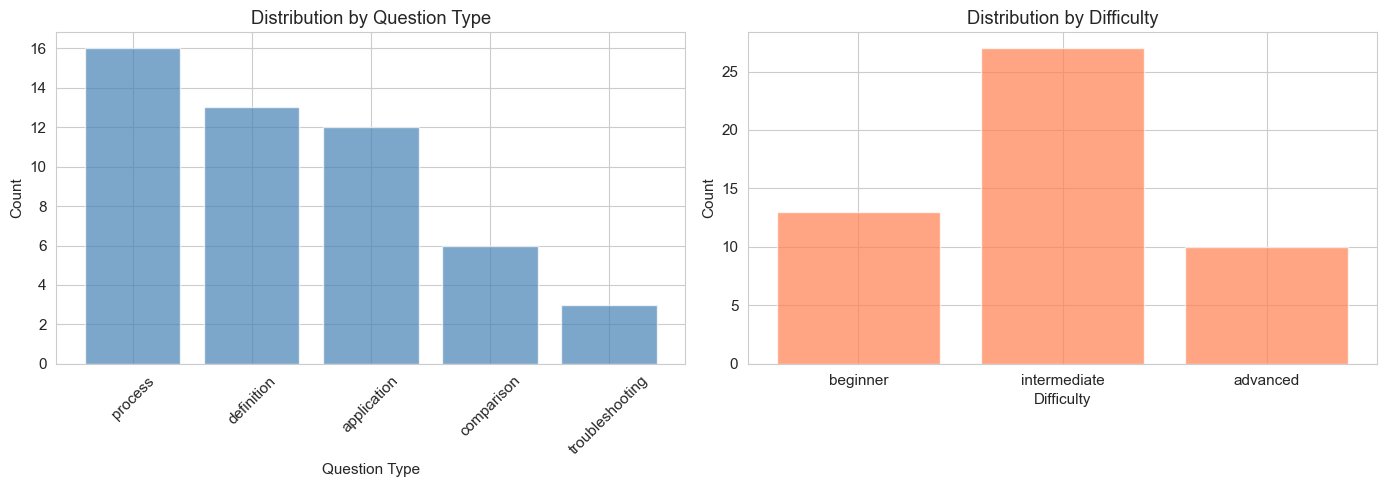


Question Type Distribution:


type
process            16
definition         13
application        12
comparison          6
troubleshooting     3
Name: count, dtype: int64


Difficulty Distribution:


difficulty
beginner        13
intermediate    27
advanced        10
Name: count, dtype: int64

In [5]:
# Question type distribution (k=5, one mode only to avoid double counting)
df_flat = df[(df['mode'] == 'flat') & (df['k'] == 5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Type
type_counts = df_flat['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Question Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution by Question Type')
axes[0].tick_params(axis='x', rotation=45)

# By Difficulty
diff_counts = df_flat['difficulty'].value_counts()
diff_order = ['beginner', 'intermediate', 'advanced']
diff_counts = diff_counts.reindex(diff_order)
axes[1].bar(diff_counts.index, diff_counts.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution by Difficulty')

plt.tight_layout()
plt.show()

print(f"\nQuestion Type Distribution:")
display(type_counts)

print(f"\nDifficulty Distribution:")
display(diff_counts)

## 5. Score Distributions (Quick Overview)

C:\Users\Julian\AppData\Local\Temp\ipykernel_256\1206853445.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_k5, x='mode', y=metric, ax=axes[idx], palette=colors)
C:\Users\Julian\AppData\Local\Temp\ipykernel_256\1206853445.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_k5, x='mode', y=metric, ax=axes[idx], palette=colors)
C:\Users\Julian\AppData\Local\Temp\ipykernel_256\1206853445.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_k5, x='mode', y=metric, ax=axes[idx], palette=colors)


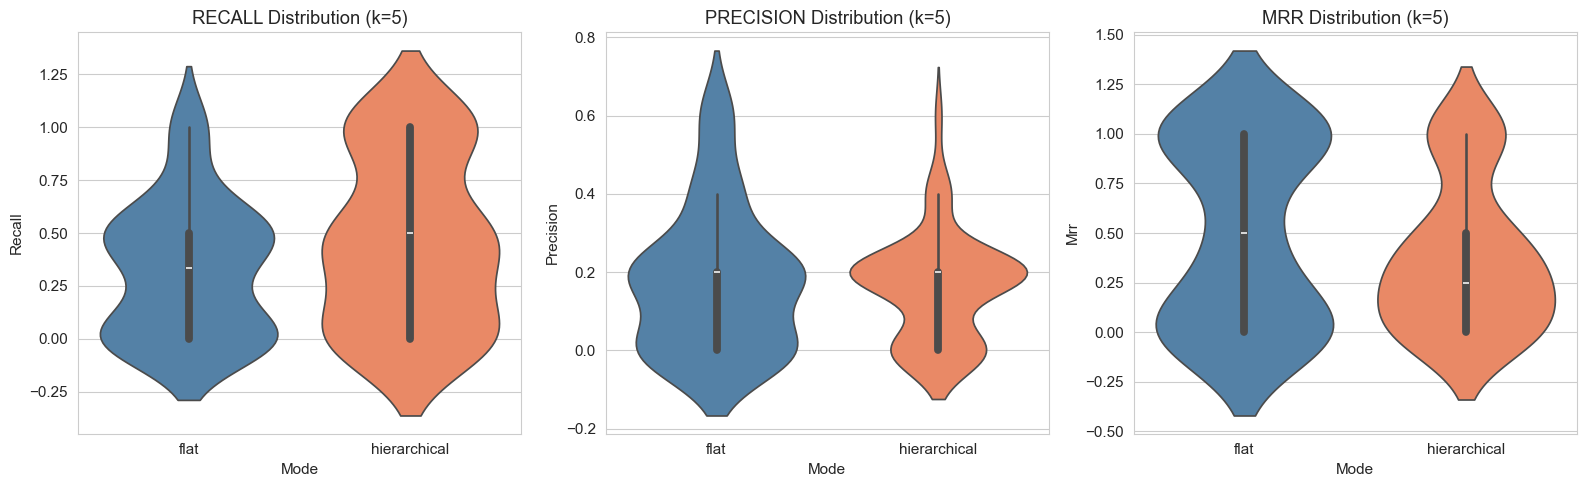

In [6]:
# Filter for k=5
df_k5 = df[df['k'] == 5]

# Create violin plots for each metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['recall', 'precision', 'mrr']
colors = ['steelblue', 'coral']

for idx, metric in enumerate(metrics):
    sns.violinplot(data=df_k5, x='mode', y=metric, ax=axes[idx], palette=colors)
    axes[idx].set_title(f'{metric.upper()} Distribution (k=5)')
    axes[idx].set_xlabel('Mode')
    axes[idx].set_ylabel(metric.capitalize())

plt.tight_layout()
plt.show()

## 6. Summary Statistics by Mode

In [7]:
# Summary for k=5
summary = df_k5.groupby('mode')[['recall', 'precision', 'mrr']].agg(['mean', 'std', 'min', 'max'])

print("Summary Statistics (k=5):")
display(summary.round(4))

# Calculate improvements
flat_means = df_k5[df_k5['mode'] == 'flat'][['recall', 'precision', 'mrr']].mean()
hier_means = df_k5[df_k5['mode'] == 'hierarchical'][['recall', 'precision', 'mrr']].mean()

improvements = ((hier_means - flat_means) / flat_means * 100).round(2)

print("\n\nHierarchical vs Flat (% Improvement):")
display(improvements)

Summary Statistics (k=5):


recall                   precision                       mrr  \
                mean     std  min  max      mean     std  min  max    mean   
mode                                                                         
flat          0.3285  0.3146  0.0  1.0    0.1800  0.1818  0.0  0.6  0.4980   
hierarchical  0.4531  0.3920  0.0  1.0    0.1625  0.1347  0.0  0.6  0.3747   

                                
                 std  min  max  
mode                            
flat          0.4586  0.0  1.0  
hierarchical  0.3676  0.0  1.0



Hierarchical vs Flat (% Improvement):


recall       37.93
precision    -9.72
mrr         -24.77
dtype: float64

## 7. Key Observations

**Notizen basierend auf den Daten:**

1. **Datenvollständigkeit:** 
   - Gesamtzahl der Auswertungen
   - Fehlende Fragen identifiziert

2. **Score-Verteilungen:**
   - Hierarchical: Höherer Recall, niedrigerer MRR
   - Trade-off zwischen Retrieval-Menge und Ranking-Qualität

3. **Kategorien:**
   - Verteilung über Fragentypen ausgewogen
   - Schwierigkeitsgrade gut repräsentiert

**→ Daten sind bereit für detaillierte Visualisierung in Notebook 02!**

---
**Next:** `02_results_analysis.ipynb` für finale Thesis-Visualisierungen